## Estimating Equine Body Weight from Single Images Using Extended Keypoints

This notebook contains the code to answer these research questions. Detailed analysis can be seen in the related research paper.

**RQ1:** Can image-derived body measurements be used to estimate equine body weight, and which measurements are most predictive?<br>
**RQ2:** How do body posture and image perspective affect the accuracy of image-based weight estimation? <br>
**RQ3:** Can equine body weight be estimated reliably from a single image when withers height is unknown and only pixel-based measurements are available?

#### Load Python Pakages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, mean_absolute_percentage_error
from audmetric import concordance_cc
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from pygam import LinearGAM
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_selection import RFECV
import json
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, SelectFromModel, f_regression
import joblib
from sklearn.inspection import permutation_importance

c:\Users\HKA\anaconda3\envs\pytorch_testenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Data

In [ ]:
# Loading the body measurements in meter or pixel and the perspective labels for the horses

df = pd.read_csv("../data/weights_bm_meter.csv")
#df = pd.read_csv("../data/weights_bm_pixel.csv")
more_labels = pd.read_csv("../data/labels_perspective.csv", sep = ";")

df.head()

,ID,Typ,Gewicht,image_name,poll_withers,poll_shoulder,poll_elbow,poll_croup,poll_hip,poll_dock,...,carpus_height,front_fetlock_height,hock_height,hind_fetlock_height,girth_height,lower_neck_height,back_height,throat_height,belly_height,belly_end_height
0,1,Warmblut,565.0,001_020725_3.jpg,99.0,106.0,142.0,183.0,183.0,226.0,...,49.0,21.0,51.0,17.0,89.0,123.0,161.0,164.0,86.0,101.0
1,1,Warmblut,565.0,001_020725_1.jpg,88.0,106.0,138.0,169.0,180.0,210.0,...,48.0,21.0,53.0,19.0,90.0,126.0,159.0,165.0,86.0,100.0
2,1,Warmblut,565.0,001_020725_2.jpg,91.0,99.0,131.0,179.0,176.0,225.0,...,50.0,21.0,57.0,18.0,92.0,121.0,162.0,156.0,90.0,108.0
3,2,Warmblut,591.0,002_030725_1.JPG,108.0,105.0,144.0,195.0,193.0,241.0,...,45.0,20.0,53.0,16.0,81.0,112.0,151.0,149.0,79.0,99.0
4,2,Warmblut,591.0,002_030725_2.JPG,104.0,104.0,143.0,185.0,184.0,230.0,...,45.0,20.0,54.0,17.0,83.0,115.0,149.0,157.0,80.0,98.0


#### Splitting the Dataset in Train and Test Data

In [5]:
# Splitting the Dataset into train and test with approx. 80% of the data for training and 20% for testing.
# We take care to have one horse with the same id in either the training or test set, but not in both.
# We will stratify the split based on the median weight of each horse to ensure that the distribution of weights is similar in both sets.
id_targets = (
    df
    .groupby("ID")["Gewicht"]
    .median()
)

n_bins = min(10, max(2, len(id_targets) // 5))

weight_bins = pd.qcut(
    id_targets,
    q=n_bins,
    labels=False,
    duplicates="drop"
)

train_ids, test_ids = train_test_split(
    id_targets.index,
    test_size=0.20,
    random_state=42,
    stratify=weight_bins
)

df_train = df[df["ID"].isin(train_ids)].copy()
df_test = df[df["ID"].isin(test_ids)].copy()

df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

In [6]:
target_col = "Gewicht"

exclude_cols = [
    target_col,
    "ID",  
]

feature_cols = (
    df_train
    .select_dtypes(include=np.number)
    .columns
    .difference(exclude_cols)
    .tolist()
)

X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

In [10]:
# Stratified Group K-Fold Cross Validation
groups_train = df_train.loc[X_train.index, "ID"]

id_targets_train = (
    df_train
    .groupby("ID")["Gewicht"]
    .median()
)

n_bins = min(10, max(2, len(id_targets_train) // 5))

weight_bins_train = pd.qcut(
    id_targets_train,
    q=n_bins,
    labels=False,
    duplicates="drop"
)

stratify_train = groups_train.map(weight_bins_train)

group_cv_st = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_splits = list(
    group_cv_st.split(
        X_train,
        stratify_train,
        groups=groups_train
    )
)

In [11]:
# Define scoring metrics for model evaluation
scoring = {
    "mae": make_scorer(
        mean_absolute_error,
        greater_is_better=False
    ),
    "rmse": make_scorer(
        root_mean_squared_error,
        greater_is_better=False
    ),
    "mape": make_scorer(
        mean_absolute_percentage_error,
        greater_is_better=False
    ),
    "ccc": make_scorer(
        concordance_cc,
        greater_is_better=True
    )
}

#### Baseline Model

In [12]:
# Train a baseline model, which predicts the mean value of all horses
baseline_model = DummyRegressor(strategy="mean")

baseline_scores = cross_validate(
    estimator=baseline_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

In [13]:
baseline_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-baseline_scores["test_mae"]).mean(),
        (-baseline_scores["test_rmse"]).mean(),
        (-baseline_scores["test_mape"]).mean() * 100,
        baseline_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-baseline_scores["test_mae"]).std(),
        (-baseline_scores["test_rmse"]).std(),
        (-baseline_scores["test_mape"]).std() * 100,
        baseline_scores["test_ccc"].std()
    ]
})

print(baseline_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      51.765               7.334
1  RMSE [kg]      61.339               8.053
2   MAPE [%]      10.582               1.910
3        CCC      -0.000               0.000


### Multiple Linear Regression (MLR)

In [14]:
mlr_model = LinearRegression()

mlr_scores = cross_validate(
    estimator=mlr_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

In [15]:
mlr_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-mlr_scores["test_mae"]).mean(),
        (-mlr_scores["test_rmse"]).mean(),
        (-mlr_scores["test_mape"]).mean() * 100,
        mlr_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-mlr_scores["test_mae"]).std(),
        (-mlr_scores["test_rmse"]).std(),
        (-mlr_scores["test_mape"]).std() * 100,
        mlr_scores["test_ccc"].std()
    ]
})

print(mlr_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      52.940               5.058
1  RMSE [kg]      66.721               6.164
2   MAPE [%]      10.734               1.346
3        CCC       0.487               0.108


### Generalized Additive Model (GAM)

In [ ]:
# Define an Optuna objective function for hyperparameter optimization of the LinearGAM model

def objective(trial):

    n_splines = trial.suggest_int(
        "n_splines",
        4,
        15
    )

    lam = trial.suggest_float(
        "lam",
        1e-4,
        1e1,
        log=True
    )

    gam_model = LinearGAM(
        n_splines=n_splines,
        lam=lam
    )

    scores = cross_validate(
        estimator=gam_model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mean_rmse = -scores["test_rmse"].mean()

    return mean_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.enqueue_trial({
    "n_splines": 5,
    "lam": 0.6
})

study.optimize(
    objective,
    n_trials=21,
    show_progress_bar=True
)

print("Bester CV-RMSE:", study.best_value)
print("Beste Parameter:", study.best_params)

In [18]:
with open("../model-parameters/best_params_gam_cv.json", "r") as f:
    best_params_cv_gam = json.load(f)

In [ ]:
# Train the GAM model with the best hyperparameters found by Optuna

best_gam_model = LinearGAM(
    **best_params_cv_gam
)


best_gam_scores = cross_validate(
    estimator=best_gam_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

best_gam_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-best_gam_scores["test_mae"]).mean(),
        (-best_gam_scores["test_rmse"]).mean(),
        (-best_gam_scores["test_mape"]).mean() * 100,
        best_gam_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-best_gam_scores["test_mae"]).std(),
        (-best_gam_scores["test_rmse"]).std(),
        (-best_gam_scores["test_mape"]).std() * 100,
        best_gam_scores["test_ccc"].std()
    ]
})

print(best_gam_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      34.402               4.455
1  RMSE [kg]      42.014               5.042
2   MAPE [%]       6.961               0.471
3        CCC       0.646               0.103


### Random Forest (RF)

In [ ]:
# Define an Optuna objective function for hyperparameter optimization of the RandomForestRegressor model

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            800,
            step=100
        ),
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            30
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            30
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            20
        ),
        "max_features": trial.suggest_float(
            "max_features",
            0.2,
            1.0
        )
    }

    rf_model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=1
    )

    scores = cross_validate(
        estimator=rf_model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
        error_score="raise"
    )
    mean_rmse = -scores["test_rmse"].mean()

    return mean_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=21,
    show_progress_bar=True
)

print("Bester CV-RMSE:", study.best_value)
print("Beste Parameter:", study.best_params)

In [20]:
with open("../model-parameters/best_params_rf_cv.json", "r") as f:
    best_params_cv_rf = json.load(f)

In [21]:
best_rf_model = RandomForestRegressor(
    **best_params_cv_rf,
    random_state=42
)


best_rf_scores = cross_validate(
    estimator=best_rf_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

best_rf_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-best_rf_scores["test_mae"]).mean(),
        (-best_rf_scores["test_rmse"]).mean(),
        (-best_rf_scores["test_mape"]).mean() * 100,
        best_rf_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-best_rf_scores["test_mae"]).std(),
        (-best_rf_scores["test_rmse"]).std(),
        (-best_rf_scores["test_mape"]).std() * 100,
        best_rf_scores["test_ccc"].std()
    ]
})

print(best_rf_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      33.569               3.800
1  RMSE [kg]      40.030               3.461
2   MAPE [%]       6.825               0.719
3        CCC       0.683               0.087


### Extreme Gradient Boosting (XGB)

In [ ]:
# Define an Optuna objective function for hyperparameter optimization of the XGBRegressor model

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 1500, step=100
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.3, log=True
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 2, 12
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 0.5, 20.0, log=True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.5, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.5, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 1e-8, 10.0, log=True
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 100.0, log=True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 100.0, log=True
        )
    }

    xgb_model = xgb.XGBRegressor(
        **params,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=1,
        verbosity=0
    )

    scores = cross_validate(
        estimator=xgb_model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
        error_score="raise"
    )
    mean_rmse = -scores["test_rmse"].mean()

    return mean_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=21,
    show_progress_bar=True
)

print("Bester CV-RMSE:", study.best_value)
print("Beste Parameter:", study.best_params)

In [22]:
with open("../model-parameters/best_params_xgb_cv.json", "r") as f:
    best_params_cv_xgb = json.load(f)

In [23]:
# Train the XGB model with the best hyperparameters found by Optuna

best_xgb_model = xgb.XGBRegressor(
    **best_params_cv_xgb,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
    verbosity=0
)


best_xgb_scores = cross_validate(
    estimator=best_xgb_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

best_xgb_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-best_xgb_scores["test_mae"]).mean(),
        (-best_xgb_scores["test_rmse"]).mean(),
        (-best_xgb_scores["test_mape"]).mean() * 100,
        best_xgb_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-best_xgb_scores["test_mae"]).std(),
        (-best_xgb_scores["test_rmse"]).std(),
        (-best_xgb_scores["test_mape"]).std() * 100,
        best_xgb_scores["test_ccc"].std()
    ]
})

print(best_xgb_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      33.160               4.228
1  RMSE [kg]      39.784               4.021
2   MAPE [%]       6.768               0.865
3        CCC       0.692               0.100


### Support Vector Regression (SVR)

In [ ]:
# Define an Optuna objective function for hyperparameter optimization of the SVR model

def objective(trial):

    kernel = trial.suggest_categorical(
        "kernel",
        ["linear", "rbf", "poly", "sigmoid"]
    )

    svr_params = {
        "kernel": kernel,
        "C": trial.suggest_float(
            "C", 1e-3, 1e3, log=True
        ),
        "epsilon": trial.suggest_float(
            "epsilon", 1e-3, 1e2, log=True
        ),
        "cache_size": 2000
    }

    if kernel in ["rbf", "poly", "sigmoid"]:
        svr_params["gamma"] = trial.suggest_float(
            "gamma", 1e-6, 1e1, log=True
        )

    if kernel == "poly":
        svr_params["degree"] = trial.suggest_int(
            "degree", 2, 5
        )
        svr_params["coef0"] = trial.suggest_float(
            "coef0", -2.0, 2.0
        )

    if kernel == "sigmoid":
        svr_params["coef0"] = trial.suggest_float(
            "coef0", -2.0, 2.0
        )

    svr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(**svr_params))
    ])

    scores = cross_validate(
        estimator=svr_pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
        error_score=np.nan
    )

    mean_rmse = -scores["test_rmse"].mean()

    return mean_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=21,
    show_progress_bar=True
)

print("Bester CV-RMSE:", study.best_value)
print("Beste Parameter:", study.best_params)

In [24]:
with open("../model-parameters/best_params_svr_cv.json", "r") as f:
    best_params_cv_svr = json.load(f)

In [25]:
# Train the SVR model with the best hyperparameters found by Optuna

best_svr_params = {
    **best_params_cv_svr,
    "cache_size": 2000
}

best_svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(**best_svr_params))
])



best_svr_scores = cross_validate(
    estimator=best_svr_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise"
)

best_svr_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-best_svr_scores["test_mae"]).mean(),
        (-best_svr_scores["test_rmse"]).mean(),
        (-best_svr_scores["test_mape"]).mean() * 100,
        best_svr_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-best_svr_scores["test_mae"]).std(),
        (-best_svr_scores["test_rmse"]).std(),
        (-best_svr_scores["test_mape"]).std() * 100,
        best_svr_scores["test_ccc"].std()
    ]
})

print(best_svr_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      36.580               3.683
1  RMSE [kg]      44.030               5.378
2   MAPE [%]       7.452               0.570
3        CCC       0.644               0.087


### Multi-Layer Perceptron (MLP)

In [ ]:
# Define an Optuna objective function for hyperparameter optimization of the MLPRegressor model

def objective(trial):

    n_layers = trial.suggest_int("n_layers", 1, 3)

    hidden_layer_sizes = tuple(
        trial.suggest_int(
            f"n_units_layer_{layer}",
            4,
            128,
            log=True
        )
        for layer in range(n_layers)
    )

    solver = trial.suggest_categorical(
        "solver",
        ["lbfgs", "adam"]
    )

    mlp_params = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": trial.suggest_categorical(
            "activation",
            ["relu", "tanh", "logistic"]
        ),
        "solver": solver,
        "alpha": trial.suggest_float(
            "alpha",
            1e-6,
            1e1,
            log=True
        ),
        "max_iter": 2000,
        "random_state": 42
    }

    if solver == "lbfgs":
        mlp_params["max_fun"] = trial.suggest_int(
            "max_fun",
            10000,
            50000,
            step=5000
        )

    if solver == "adam":
        mlp_params["learning_rate_init"] = trial.suggest_float(
            "learning_rate_init",
            1e-5,
            1e-1,
            log=True
        )

        mlp_params["batch_size"] = trial.suggest_categorical(
            "batch_size",
            ["auto", 16, 32, 64, 128]
        )

        mlp_params["early_stopping"] = trial.suggest_categorical(
            "early_stopping",
            [True, False]
        )

        mlp_params["n_iter_no_change"] = trial.suggest_int(
            "n_iter_no_change",
            10,
            50,
            step=10
        )

    mlp_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(**mlp_params))
    ])

    scores = cross_validate(
        estimator=mlp_pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
        error_score=np.nan
    )


    mean_rmse = -scores["test_rmse"].mean()

    return mean_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.enqueue_trial({
    "n_layers": 1,
    "n_units_layer_0": 8,
    "activation": "relu",
    "solver": "lbfgs",
    "alpha": 0.01,
    "max_fun": 15000
})


study.optimize(
    objective,
    n_trials=21,
    show_progress_bar=True
)

print("Bester CV-RMSE:", study.best_value)
print("Beste Parameter:", study.best_params)

In [26]:
with open("../model-parameters/best_params_mlp_cv.json", "r") as f:
    best_params_cv_mlp = json.load(f)

In [27]:
def create_mlp_from_best_params(best_params):

    hidden_layer_sizes = tuple(
        best_params[f"n_units_layer_{layer}"]
        for layer in range(best_params["n_layers"])
    )

    solver = best_params["solver"]

    mlp_params = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": best_params["activation"],
        "solver": solver,
        "alpha": best_params["alpha"],
        "max_iter": 2000,
        "random_state": 42
    }

    if solver == "lbfgs":
        mlp_params["max_fun"] = best_params["max_fun"]

    if solver == "adam":
        mlp_params.update({
            "learning_rate_init":
                best_params["learning_rate_init"],
            "batch_size":
                best_params["batch_size"],
            "early_stopping":
                best_params["early_stopping"],
            "n_iter_no_change":
                best_params["n_iter_no_change"]
        })

    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(**mlp_params))
    ])

best_mlp_model = create_mlp_from_best_params(
    best_params_cv_mlp
)



best_mlp_scores = cross_validate(
    estimator=best_mlp_model,
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise"
)

best_mlp_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-best_mlp_scores["test_mae"]).mean(),
        (-best_mlp_scores["test_rmse"]).mean(),
        (-best_mlp_scores["test_mape"]).mean() * 100,
        best_mlp_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-best_mlp_scores["test_mae"]).std(),
        (-best_mlp_scores["test_rmse"]).std(),
        (-best_mlp_scores["test_mape"]).std() * 100,
        best_mlp_scores["test_ccc"].std()
    ]
})

print(best_mlp_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      37.465               4.035
1  RMSE [kg]      45.074               7.222
2   MAPE [%]       7.673               0.875
3        CCC       0.651               0.107


### Feature Selection

##### Testing Formular Feature

In [31]:
# Test 1 - Feature similar to the formular of Carroll & Huntington
feature_cols_t1 = ["shoulder_dock", "girth_back"]

X_train_t1 = df_train[feature_cols_t1]

In [34]:
# Train a multiple linear regression model with the selected features

mlr_t1_scores = cross_validate(
    estimator=mlr_model,
    X=X_train_t1,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

mlr_t1_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-mlr_t1_scores["test_mae"]).mean(),
        (-mlr_t1_scores["test_rmse"]).mean(),
        (-mlr_t1_scores["test_mape"]).mean() * 100,
        mlr_t1_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-mlr_t1_scores["test_mae"]).std(),
        (-mlr_t1_scores["test_rmse"]).std(),
        (-mlr_t1_scores["test_mape"]).std() * 100,
        mlr_t1_scores["test_ccc"].std()
    ]
})

print(mlr_t1_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      40.941               6.659
1  RMSE [kg]      49.662               6.323
2   MAPE [%]       8.298               1.466
3        CCC       0.467               0.112


In [32]:
# Random Forest model with the selected feature

rf_t1_scores = cross_validate(
    estimator=best_rf_model,
    X=X_train_t1,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

rf_t1_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-rf_t1_scores["test_mae"]).mean(),
        (-rf_t1_scores["test_rmse"]).mean(),
        (-rf_t1_scores["test_mape"]).mean() * 100,
        rf_t1_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-rf_t1_scores["test_mae"]).std(),
        (-rf_t1_scores["test_rmse"]).std(),
        (-rf_t1_scores["test_mape"]).std() * 100,
        rf_t1_scores["test_ccc"].std()
    ]
})

print(rf_t1_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      41.233               5.942
1  RMSE [kg]      50.893               7.064
2   MAPE [%]       8.425               1.487
3        CCC       0.399               0.111


In [33]:
# XGB model with the selected feature

xgb_t1_scores = cross_validate(
    estimator=best_xgb_model,
    X=X_train_t1,
    y=y_train,
    groups=groups_train,
    cv=cv_splits,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

xgb_t1_summary = pd.DataFrame({
    "Metrik": [
        "MAE [kg]",
        "RMSE [kg]",
        "MAPE [%]",
        "CCC"
    ],
    "Mittelwert": [
        (-xgb_t1_scores["test_mae"]).mean(),
        (-xgb_t1_scores["test_rmse"]).mean(),
        (-xgb_t1_scores["test_mape"]).mean() * 100,
        xgb_t1_scores["test_ccc"].mean()
    ],
    "Standardabweichung": [
        (-xgb_t1_scores["test_mae"]).std(),
        (-xgb_t1_scores["test_rmse"]).std(),
        (-xgb_t1_scores["test_mape"]).std() * 100,
        xgb_t1_scores["test_ccc"].std()
    ]
})

print(xgb_t1_summary.round(3))

      Metrik  Mittelwert  Standardabweichung
0   MAE [kg]      50.325               7.031
1  RMSE [kg]      61.366               8.578
2   MAPE [%]      10.283               1.888
3        CCC       0.304               0.077


##### Select k best Feature based on the Models

In [28]:
n_features = X_train.shape[1]

k_values = np.unique(
    np.geomspace(
        5,
        n_features,
        num=12,
        dtype=int
    )
).tolist()

k_values.append("all")


results = []

for k in k_values:

    mlr_model = Pipeline([
        ("feature_selection", SelectKBest(
            score_func=f_regression,
            k=k
        )),
        ("model", LinearRegression())
    ])

    scores = cross_validate(
        estimator=mlr_model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "k": k,
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),

        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),

        "MAPE_mean": -scores["test_mape"].mean(),
        "MAPE_std": scores["test_mape"].std(),

        "CCC_mean": scores["test_ccc"].mean(),
        "CCC_std": scores["test_ccc"].std()
    })


results_df = pd.DataFrame(results)

print(
    results_df.sort_values("RMSE_mean")
)

      k   MAE_mean    MAE_std   RMSE_mean   RMSE_std  MAPE_mean  MAPE_std  \
0     5  34.823672   5.340952   42.181151   8.426423   0.070187  0.009944   
1     7  36.228261   4.392629   43.383003   7.717624   0.073086  0.008496   
2     9  36.999039   5.378181   44.190047   8.635173   0.074522  0.010473   
5    27  37.936762   5.840428   45.234818   9.069087   0.077058  0.013821   
3    13  37.688485   7.048339   45.926655   9.486848   0.076034  0.013755   
4    19  39.204041   6.298891   47.255755   8.686117   0.078947  0.012012   
6    38  39.802228   8.327517   48.806855  11.752655   0.081038  0.019255   
7    53  41.772920   7.881331   52.454065  11.481765   0.085366  0.019842   
8    75  50.450362   7.989014   64.361716  11.086316   0.102622  0.020576   
11  208  52.940003   5.058334   66.721170   6.163921   0.107335  0.013455   
12  all  52.940003   5.058334   66.721170   6.163921   0.107335  0.013455   
9   105  83.354322  16.857374  102.726696  17.648061   0.169281  0.035858   

In [29]:
results = []

n_features = X_train.shape[1]

k_values = np.unique(
    np.geomspace(
        5,
        n_features,
        num=12,
        dtype=int
    )
).tolist()

for k in k_values:

    rf_selector = RandomForestRegressor(
        **best_params_cv_rf,
        random_state=42
    )

    rf_model = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=rf_selector,
                threshold=-np.inf,
                max_features=k
            )
        ),
        (
            "model",
            RandomForestRegressor(
                **best_params_cv_rf,
                random_state=42
            )
        )
    ])

    scores = cross_validate(
        estimator=rf_model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "k": k,

        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),

        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),

        "MAPE_mean": -scores["test_mape"].mean(),
        "MAPE_std": scores["test_mape"].std(),

        "CCC_mean": scores["test_ccc"].mean(),
        "CCC_std": scores["test_ccc"].std()
    })


results_df = pd.DataFrame(results)

print(
    results_df.sort_values("RMSE_mean")
)

      k   MAE_mean   MAE_std  RMSE_mean  RMSE_std  MAPE_mean  MAPE_std  \
6    38  32.966728  4.296534  39.493578  3.870734   0.067096  0.008330   
3    13  32.947125  4.604739  39.861464  4.682288   0.066777  0.008545   
8    75  33.364696  3.706820  39.873258  3.346665   0.067882  0.007375   
9   105  33.614783  4.055535  39.883501  3.980624   0.068406  0.008027   
7    53  33.518717  4.326650  39.904550  3.967236   0.068222  0.008235   
1     7  33.895405  5.051482  39.962869  5.235722   0.068538  0.009504   
5    27  33.202307  4.565216  39.971381  4.004126   0.067515  0.008504   
4    19  33.321875  4.031197  40.028755  4.127578   0.067631  0.007521   
11  208  33.568830  3.800024  40.029832  3.461470   0.068252  0.007193   
10  148  33.811454  3.664323  40.269853  3.523065   0.068727  0.006469   
2     9  33.741259  5.125814  40.354988  4.966395   0.068267  0.009305   
0     5  34.828244  4.578282  41.080103  5.411068   0.070187  0.008159   

    CCC_mean   CCC_std  
6   0.692002

In [ ]:
n_features = X_train.shape[1]

k_values = np.unique(
    np.geomspace(
        5,
        n_features,
        num=12,
        dtype=int
    )
).tolist()


results = []

for k in k_values:

    selector_model = xgb.XGBRegressor(
        **best_params_cv_xgb,
        random_state=42,
        n_jobs=1
    )

    xgb_pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=selector_model,
                threshold=-np.inf,
                max_features=k
            )
        ),
        (
            "model",
            xgb.XGBRegressor(
                **best_params_cv_xgb,
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=xgb_pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "k": k,

        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std(),

        "RMSE_mean": -scores["test_rmse"].mean(),
        "RMSE_std": scores["test_rmse"].std(),

        "MAPE_mean": -scores["test_mape"].mean(),
        "MAPE_std": scores["test_mape"].std(),

        "CCC_mean": scores["test_ccc"].mean(),
        "CCC_std": scores["test_ccc"].std()
    })


results_df = pd.DataFrame(results).sort_values("RMSE_mean")

print(results_df)

best_k = int(results_df.iloc[0]["k"])
print("Best k:", best_k)

      k   MAE_mean   MAE_std  RMSE_mean  RMSE_std  MAPE_mean  MAPE_std  \
10  148  32.305011  4.343692  39.056125  4.164266   0.065982  0.009024   
9   105  32.840830  4.658933  39.379475  4.715827   0.066907  0.009413   
8    75  32.393188  4.048290  39.591650  3.588269   0.065704  0.007894   
11  208  33.160132  4.227655  39.783572  4.021249   0.067681  0.008648   
7    53  32.409368  3.553719  40.050020  3.521649   0.065969  0.007256   
5    27  33.482995  3.929661  40.422775  3.950274   0.068213  0.008659   
6    38  32.967445  4.259032  40.458730  4.331448   0.067349  0.008994   
4    19  32.665631  5.928458  40.491786  6.227749   0.066569  0.012819   
3    13  32.914000  4.994275  40.650852  4.517596   0.066892  0.010995   
2     9  34.636104  5.686157  41.837605  5.050871   0.069805  0.010729   
1     7  34.800734  5.997882  42.952046  5.630798   0.069664  0.011170   
0     5  37.293969  6.618161  44.284473  7.215156   0.074158  0.011630   

    CCC_mean   CCC_std  
10  0.701682

### Hyperparameter tuning and final models

In [35]:
# train the final multiple linear regression model with the best k features

best_k = 5

final_mlr = Pipeline([
    (
        "feature_selection",
        SelectKBest(
            score_func=f_regression,
            k=best_k
        )
    ),
    (
        "model",
        LinearRegression()
    )
])


final_mlr.fit(X_train, y_train)

selector = final_mlr.named_steps["feature_selection"]

selected_features_mlr = X_train.columns[
    selector.get_support()
]

print(f"Anzahl ausgewählter Features: {len(selected_features_mlr)}")
print(selected_features_mlr.tolist())

y_pred_mlr = final_mlr.predict(X_test)

test_results_mlr = {
    "MAE": mean_absolute_error(y_test, y_pred_mlr),
    "RMSE": root_mean_squared_error(y_test, y_pred_mlr),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_mlr),
    "CCC": concordance_cc(y_test, y_pred_mlr)
}

test_results_mlr = pd.Series(test_results_mlr)

print("\nFinal Test Performance:")
print(test_results_mlr)

Anzahl ausgewählter Features: 5
['back_height', 'front_hoof_back', 'withers_front_fetlock', 'withers_front_hoof', 'withers_height']

Final Test Performance:
MAE     34.899893
RMSE    42.730724
MAPE     0.071969
CCC      0.635265
dtype: float64


In [ ]:
# Train the final Random Forest model with the best k features

best_k = 38

selector_rf_params = best_params_cv_rf

def objective(trial):

    rf_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                800,
                step=100
            ),
            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                30
            ),
            "min_samples_split": trial.suggest_int(
                "min_samples_split",
                2,
                30
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                20
            ),
            "max_features": trial.suggest_float(
                "max_features",
                0.2,
                1.0
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=RandomForestRegressor(
                    **selector_rf_params,
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            RandomForestRegressor(
                **rf_params,
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=False
)

best_rf_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_rf_params)


final_rf = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=RandomForestRegressor(
                **selector_rf_params,
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        )
    )
])

final_rf.fit(X_train, y_train)

selector = final_rf.named_steps["feature_selection"]

selected_features_rf = X_train.columns[
    selector.get_support()
]

In [ ]:
# loading the trained models and selected features (results of the hyperparameter tuning and feature selection)

final_rf = joblib.load("../model-parameters/final_rf.pkl")
selected_features_rf = joblib.load("../model-parameters/final_rf_info.pkl")["features"]

In [ ]:
# Results of the Random Forest model on the test set

print(f"Selected Features: {len(selected_features_rf)}")

y_pred_rf = final_rf.predict(X_test)

test_results_rf = {
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": root_mean_squared_error(y_test, y_pred_rf),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_rf),
    "CCC": concordance_cc(y_test, y_pred_rf)
}

print(pd.Series(test_results_rf))

Selected Features: 38
MAE     29.682911
RMSE    38.867921
MAPE     0.062389
CCC      0.733888
dtype: float64


In [ ]:
# Train the final XGB model with the best k features

best_k = 148

selector_xgb_params = best_params_cv_xgb


def objective(trial):

    xgb_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 1500, step=100
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 2, 12
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight", 0.5, 20.0, log=True
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.5, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.5, 1.0
            ),
            "gamma": trial.suggest_float(
                "gamma", 1e-8, 10.0, log=True
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-8, 100.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-8, 100.0, log=True
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=xgb.XGBRegressor(
                    **selector_xgb_params,
                    importance_type="gain",
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            xgb.XGBRegressor(
                **xgb_params,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()


study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100
)

best_xgb_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_xgb_params)

final_xgb = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=xgb.XGBRegressor(
                **selector_xgb_params,
                importance_type="gain",
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        xgb.XGBRegressor(
            **best_xgb_params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
])

final_xgb.fit(X_train, y_train)

selector = final_xgb.named_steps["feature_selection"]

selected_features_xgb = X_train.columns[
    selector.get_support()
]

In [ ]:
# loading the trained models and selected features (results of the hyperparameter tuning and feature selection)

final_xgb = joblib.load("../model-parameters/final_xgb.pkl")
selected_features_xgb = joblib.load("../model-parameters/final_xgb_info.pkl")["features"]

In [ ]:
# Results of the XGB model on the test set

print(f"Selected Features: {len(selected_features_xgb)}")

y_pred_xgb = final_xgb.predict(X_test)

test_results_xgb = {
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": root_mean_squared_error(y_test, y_pred_xgb),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_xgb),
    "CCC": concordance_cc(y_test, y_pred_xgb)
}

print(pd.Series(test_results_xgb))

Selected Features: 148
MAE     30.371214
RMSE    41.524286
MAPE     0.064128
CCC      0.697339
dtype: float64


### Evaluation

#### Comparing Models visually

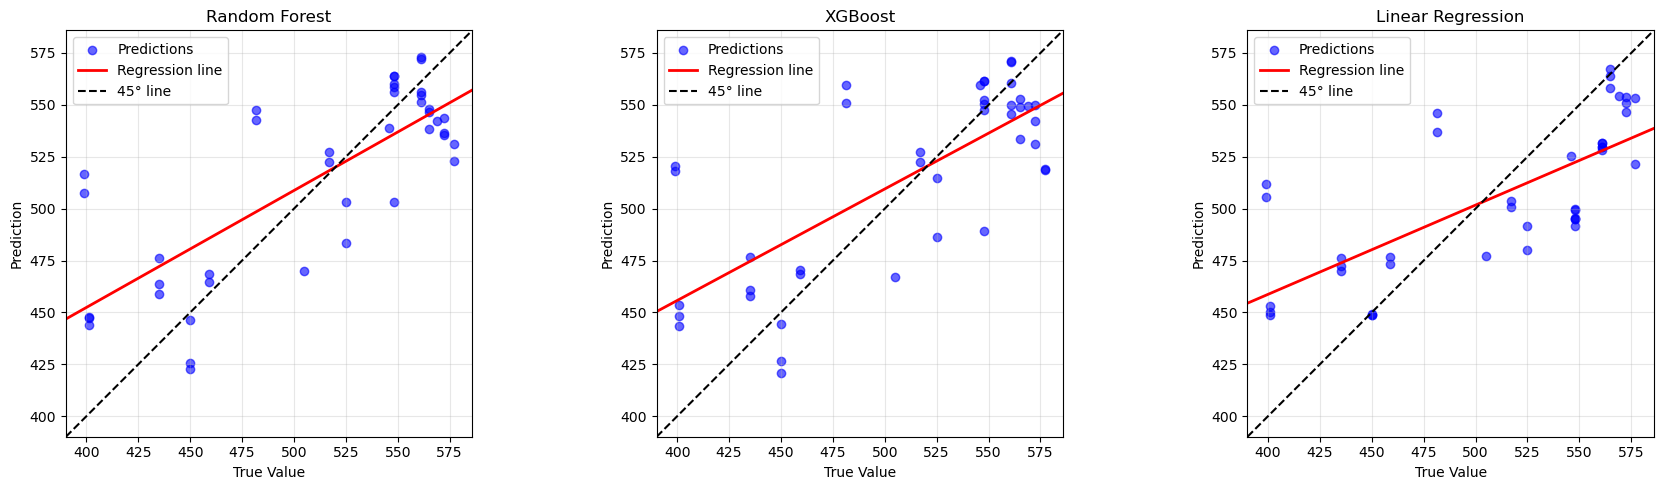

In [ ]:
# Generation of the plot to compare the predictions of the three models (Random Forest, XGBoost, and Multiple Linear Regression) with the true values

y_true = np.asarray(y_test).ravel()

predictions = {
    "Random Forest": np.asarray(y_pred_rf).ravel(),
    "XGBoost": np.asarray(y_pred_xgb).ravel(),
    "Linear Regression": np.asarray(y_pred_mlr).ravel()
}

all_values = np.concatenate(
    [y_true] + list(predictions.values())
)

axis_min = all_values.min()
axis_max = all_values.max()

margin = 0.05 * (axis_max - axis_min)
axis_min -= margin
axis_max += margin

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
)

for ax, (model_name, y_pred) in zip(axes, predictions.items()):

    ax.scatter(
        y_true,
        y_pred,
        color="blue",
        alpha=0.6,
        label="Predictions"
    )

    slope, intercept = np.polyfit(y_true, y_pred, deg=1)

    x_line = np.linspace(axis_min, axis_max, 200)
    regression_line = slope * x_line + intercept

    ax.plot(
        x_line,
        regression_line,
        color="red",
        linewidth=2,
        label="Regression line"
    )

    ax.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="45° line"
    )

    ax.set_title(model_name)
    ax.set_xlabel("True Value")
    ax.set_ylabel("Prediction")

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)

    ax.set_aspect("equal", adjustable="box")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

#### Comparing Models by Type

In [59]:
df_test_predictions = df_test.copy()

df_test_predictions["true_value"] = np.asarray(y_test).ravel()
df_test_predictions["lr_prediction"] = np.asarray(y_pred_mlr).ravel()
df_test_predictions["rf_prediction"] = np.asarray(y_pred_rf).ravel()
df_test_predictions["xgb_prediction"] = np.asarray(y_pred_xgb).ravel()

In [ ]:
# evaluating the performance of the models on the test set for each horse type

results = []

for typ, group in df_test_predictions.groupby("Typ"):

    y_true = group["true_value"]
    y_pred = group["xgb_prediction"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    ccc = concordance_cc(y_true, y_pred)

    results.append({
        "Typ": typ,
        "n": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "CCC": ccc
    })

metrics_by_typ = pd.DataFrame(results)

print(metrics_by_typ)

metric_std = metrics_by_typ[
    ["MAE", "RMSE", "MAPE (%)", "CCC"]
].std()

print("\nStandardabweichung über die Typen:")
print(metric_std)

            Typ   n        MAE       RMSE  MAPE (%)       CCC
0        G-Pony   9  32.382833  35.248097  7.702850 -0.174973
1    Kleinpferd   4  17.394791  21.315613  3.455391  0.693892
2  Spezialrasse   8  41.683949  64.054228  9.657575  0.249088
3      Vollblut   1  13.488159  13.488159  2.470359       NaN
4      Warmblut  19  28.275546  36.048330  5.265630  0.175217

Standardabweichung über die Typen:
MAE         11.406360
RMSE        19.304368
MAPE (%)     2.971986
CCC          0.357039
dtype: float64


In [ ]:
# analysing the selected features from the three models (MLR, RF, XGB) and identifying features that are selected in exactly 2 or 3 models

feature_lists = {
    "MLR": selected_features_mlr,
    "RF": selected_features_rf,
    "XGB": selected_features_xgb
}

feature_counter = Counter()

for features in feature_lists.values():
    feature_counter.update(set(features))


features_in_2 = [
    feature for feature, count in feature_counter.items()
    if count == 2
]

features_in_3 = [
    feature for feature, count in feature_counter.items()
    if count == 3
]

print("Features in genau 2 Modellen:")
print(features_in_2)
print(len(features_in_2))

print("\nFeatures in genau 3 Modellen:")
print(features_in_3)
print(len(features_in_3))

Features in genau 2 Modellen:
['lower_neck_belly', 'girth_height', 'elbow_height', 'shoulder_front_fetlock', 'throat_belly', 'front_fetlock_back', 'elbow_belly_end', 'hip_girth', 'front_fetlock_front_hoof', 'carpus_back', 'throat_height', 'withers_carpus', 'girth_belly', 'withers_belly', 'throat_belly_end', 'carpus_hind_fetlock', 'girth_throat', 'shoulder_belly_end', 'back_belly', 'withers_elbow', 'shoulder_front_hoof', 'elbow_front_fetlock', 'front_fetlock_lower_neck', 'shoulder_belly', 'girth_belly_end', 'shoulder_height', 'lower_neck_belly_end']
27

Features in genau 3 Modellen:
['withers_front_fetlock', 'front_hoof_back', 'withers_front_hoof', 'back_height', 'withers_height']
5


## Train Model just on Images with good perspektive

In [ ]:
# creating a positive and negative subset of the training and test data based on the "perspective" column

df_train_2 = df_train.merge(
    more_labels,
    on="image_name",
    how="left"
)

df_test_2 = df_test.merge(
    more_labels,
    on="image_name",
    how="left"
)

train_subset_pos = df_train_2[df_train_2["perspective"] == 0]

test_subset_pos = df_test_2[df_test_2["perspective"] == 0]

print(f"Trainingsdaten (perspective=0): {len(train_subset_pos)} von {len(df_train_2)}")
print(f"Testdaten (perspective=0): {len(test_subset_pos)} von {len(df_test_2)}")

train_subset_neg = df_train_2[df_train_2["perspective"] != 0]

test_subset_neg = df_test_2[df_test_2["perspective"] != 0]

print(f"Trainingsdaten (perspective!=0): {len(train_subset_neg)} von {len(df_train_2)}")
print(f"Testdaten (perspective!=0): {len(test_subset_neg)} von {len(df_test_2)}")


Trainingsdaten (perspective=0): 84 von 158
Testdaten (perspective=0): 27 von 41
Trainingsdaten (perspective!=0): 74 von 158
Testdaten (perspective!=0): 14 von 41


In [68]:
X_train_pos = train_subset_pos[feature_cols]
y_train_pos = train_subset_pos[target_col]

X_test_pos = test_subset_pos[feature_cols]
y_test_pos = test_subset_pos[target_col]

X_train_neg = train_subset_neg[feature_cols]
y_train_neg = train_subset_neg[target_col]

X_test_neg = test_subset_neg[feature_cols]
y_test_neg = test_subset_neg[target_col]

In [ ]:
# Testing the performance of the three models (Random Forest, XGBoost, and Multiple Linear Regression) on the negative subset of the test data
# the variable X_test_neg can be replaced by X_test_pos to evaluate the performance on the positive subset of the test data

rf_pred = final_rf.predict(X_test_neg)
xgb_pred = final_xgb.predict(X_test_neg)
lr_pred = final_mlr.predict(X_test_neg)

predictions = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Linear Regression": lr_pred
}

results = []

for model_name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test_neg, y_pred)
    rmse = root_mean_squared_error(y_test_neg, y_pred)
    mape = mean_absolute_percentage_error(y_test_neg, y_pred)* 100
    ccc = concordance_cc(y_test_neg, y_pred)

    results.append({
        "Modell": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "CCC": ccc
    })


results_df = pd.DataFrame(results)

print(results_df.round(3))

              Modell     MAE    RMSE  MAPE (%)    CCC
0      Random Forest  32.842  37.752     6.598  0.720
1            XGBoost  33.766  40.829     6.809  0.688
2  Linear Regression  32.732  38.120     6.769  0.708


In [ ]:
# train the MLR model on the positive subset of the training data with the best k features

best_k = 5

subset_mlr = Pipeline([
    (
        "feature_selection",
        SelectKBest(
            score_func=f_regression,
            k=best_k
        )
    ),
    (
        "model",
        LinearRegression()
    )
])


subset_mlr.fit(X_train_pos, y_train_pos)

selector = subset_mlr.named_steps["feature_selection"]

selected_features_mlr = X_train_pos.columns[
    selector.get_support()
]

print(f"Anzahl ausgewählter Features: {len(selected_features_mlr)}")
print(selected_features_mlr.tolist())

Anzahl ausgewählter Features: 5
['back_height', 'front_hoof_back', 'withers_front_fetlock', 'withers_front_hoof', 'withers_height']


In [ ]:
# Evaluating the performance of the subset MLR model on the negative subset of the test data
# the variable X_test_neg can be replaced by X_test_pos to evaluate the performance on the positive subset of the test data

y_pred_mlr = subset_mlr.predict(X_test_neg)

test_results_mlr = {
    "MAE": mean_absolute_error(y_test_neg, y_pred_mlr),
    "RMSE": root_mean_squared_error(y_test_neg, y_pred_mlr),
    "MAPE": mean_absolute_percentage_error(y_test_neg, y_pred_mlr),
    "CCC": concordance_cc(y_test_neg, y_pred_mlr)
}

test_results_mlr = pd.Series(test_results_mlr)

print("\nFinal Test Performance:")
print(test_results_mlr)


Final Test Performance:
MAE     33.469822
RMSE    40.063320
MAPE     0.070095
CCC      0.692642
dtype: float64


In [ ]:
# Defining the cross-validation strategy for the positive subset of the training data

groups_train_subset = train_subset_pos.loc[X_train_pos.index, "ID_x"]

id_targets_train = (
    train_subset_pos
    .groupby("ID_x")["Gewicht"]
    .median()
)

n_bins = min(10, max(2, len(id_targets_train) // 5))

weight_bins_train = pd.qcut(
    id_targets_train,
    q=n_bins,
    labels=False,
    duplicates="drop"
)

stratify_train = groups_train_subset.map(weight_bins_train)

group_cv_subset = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_splits_subset = list(
    group_cv_subset.split(
        X_train_pos,
        stratify_train,
        groups=groups_train_subset
    )
)

In [74]:
best_params_cv_rf = joblib.load("../model-parameters/final_rf_info.pkl")["best_params"]

In [ ]:
# Training the RF Model on the positive subset of the training data with the best k features
# Using the cross validation for hyperparameter tuning

best_k = 38

selector_rf_params = best_params_cv_rf

def objective(trial):

    rf_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                800,
                step=100
            ),
            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                30
            ),
            "min_samples_split": trial.suggest_int(
                "min_samples_split",
                2,
                30
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                20
            ),
            "max_features": trial.suggest_float(
                "max_features",
                0.2,
                1.0
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=RandomForestRegressor(
                    **selector_rf_params,
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            RandomForestRegressor(
                **rf_params,
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train_pos,
        y=y_train_pos,
        groups=groups_train_subset,
        cv=cv_splits_subset,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=False
)

best_rf_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_rf_params)


subset_rf = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=RandomForestRegressor(
                **selector_rf_params,
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        )
    )
])

subset_rf.fit(X_train_pos, y_train_pos)

selector = subset_rf.named_steps["feature_selection"]

selected_features_rf = X_train_pos.columns[
    selector.get_support()
]

print(f"Selected Features: {len(selected_features_rf)}")
print(selected_features_rf.tolist())


In [ ]:
# loading the subset RF model and selected features for the following steps

subset_rf = joblib.load("../model-parameters/subset_rf.pkl")
selected_features_rf = joblib.load("../model-parameters/subset_rf_info.pkl")["features"]

In [ ]:
# evaluation of the subset RF Model on the positive subset of the test data
# the variable X_test_pos can be replaced by X_test_neg to evaluate the performance on the positive subset of the test data

y_pred_rf = subset_rf.predict(X_test_pos)

test_results_rf = {
    "MAE": mean_absolute_error(y_test_pos, y_pred_rf),
    "RMSE": root_mean_squared_error(y_test_pos, y_pred_rf),
    "MAPE": mean_absolute_percentage_error(y_test_pos, y_pred_rf),
    "CCC": concordance_cc(y_test_pos, y_pred_rf)
}

print(pd.Series(test_results_rf))

MAE     26.644648
RMSE    39.977840
MAPE     0.057044
CCC      0.730621
dtype: float64


In [77]:
best_params_cv_xgb = joblib.load("../model-parameters/final_xgb_info.pkl")["best_params"]

In [ ]:
# Training the XGB Model on the positive subset of the training data with the best k features
# Using the cross validation for hyperparameter tuning

best_k = 148

selector_xgb_params = best_params_cv_xgb


def objective(trial):

    xgb_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 1500, step=100
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 2, 12
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight", 0.5, 20.0, log=True
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.5, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.5, 1.0
            ),
            "gamma": trial.suggest_float(
                "gamma", 1e-8, 10.0, log=True
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-8, 100.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-8, 100.0, log=True
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=xgb.XGBRegressor(
                    **selector_xgb_params,
                    importance_type="gain",
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            xgb.XGBRegressor(
                **xgb_params,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train_pos,
        y=y_train_pos,
        groups=groups_train_subset,
        cv=cv_splits_subset,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()


study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100
)

best_xgb_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_xgb_params)

subset_xgb = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=xgb.XGBRegressor(
                **selector_xgb_params,
                importance_type="gain",
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        xgb.XGBRegressor(
            **best_xgb_params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
])

subset_xgb.fit(X_train_pos, y_train_pos)

selector = subset_xgb.named_steps["feature_selection"]

selected_features_xgb = X_train_pos.columns[
    selector.get_support()
]

print(f"Selected Features: {len(selected_features_xgb)}")
print(selected_features_xgb.tolist())

In [ ]:
# loading the subset XGB model and selected features for the following steps

subset_xgb = joblib.load("../model-parameters/subset_xgb.pkl")
selected_features_xgb = joblib.load("../model-parameters/final_xgb_info.pkl")["features"]

In [ ]:
# evaluation of the subset XGB Model on the positive subset of the test data
# the variable X_test_pos can be replaced by X_test_neg to evaluate the performance on the positive subset of the test data

y_pred_xgb = subset_xgb.predict(X_test_pos)

test_results_xgb = {
    "MAE": mean_absolute_error(y_test_pos, y_pred_xgb),
    "RMSE": root_mean_squared_error(y_test_pos, y_pred_xgb),
    "MAPE": mean_absolute_percentage_error(y_test_pos, y_pred_xgb),
    "CCC": concordance_cc(y_test_pos, y_pred_xgb)
}

print(pd.Series(test_results_xgb))

MAE     28.408429
RMSE    41.653034
MAPE     0.060855
CCC      0.726178
dtype: float64


In [86]:
# analyzing the selected features from the three models (MLR, RF, XGB) and identifying features that are selected in exactly 2 or 3 models

feature_lists = {
    "MLR": selected_features_mlr,
    "RF": selected_features_rf,
    "XGB": selected_features_xgb
}

feature_counter = Counter()

for features in feature_lists.values():
    feature_counter.update(set(features))


features_in_2 = [
    feature for feature, count in feature_counter.items()
    if count == 2
]

features_in_3 = [
    feature for feature, count in feature_counter.items()
    if count == 3
]

print("Features in genau 2 Modellen:")
print(features_in_2)
print(len(features_in_2))

print("\nFeatures in genau 3 Modellen:")
print(features_in_3)
print(len(features_in_3))

Features in genau 2 Modellen:
['elbow_girth', 'hind_fetlock_belly_end', 'back_throat', 'poll_belly', 'girth_height', 'shoulder_front_fetlock', 'throat_belly', 'front_fetlock_back', 'hind_fetlock_belly', 'withers_carpus', 'girth_belly', 'hip_height', 'hind_hoof_belly', 'poll_dock', 'throat_belly_end', 'girth_throat', 'back_belly', 'shoulder_front_hoof', 'croup_hind_hoof', 'dock_back', 'hip_knee', 'girth_belly_end', 'hip_hind_hoof', 'hip_dock', 'poll_front_fetlock', 'croup_height']
26

Features in genau 3 Modellen:
['withers_front_fetlock', 'front_hoof_back', 'withers_front_hoof', 'back_height', 'withers_height']
5


## Impact of Head Position

In [ ]:
# Removing all columns that contain "poll" or "throat" in their name from the feature columns for the next analysis

feature_cols_posture = [
    col for col in feature_cols
    if "poll" not in col.lower()
    and "throat" not in col.lower()
]

X_train_posture = df_train[feature_cols_posture]
y_train = df_train[target_col]

X_test_posture = df_test[feature_cols_posture]
y_test = df_test[target_col]

In [88]:
# Repeating the Feature Selection and Model Training for the Posture Subset of Features

best_k = 5

posture_mlr = Pipeline([
    (
        "feature_selection",
        SelectKBest(
            score_func=f_regression,
            k=best_k
        )
    ),
    (
        "model",
        LinearRegression()
    )
])


posture_mlr.fit(X_train_posture, y_train)

selector = posture_mlr.named_steps["feature_selection"]

selected_features_mlr = X_train_posture.columns[
    selector.get_support()
]

print(f"Anzahl ausgewählter Features: {len(selected_features_mlr)}")
print(selected_features_mlr.tolist())

Anzahl ausgewählter Features: 5
['back_height', 'front_hoof_back', 'withers_front_fetlock', 'withers_front_hoof', 'withers_height']


In [89]:
y_pred_mlr = posture_mlr.predict(X_test_posture)

test_results_mlr = {
    "MAE": mean_absolute_error(y_test, y_pred_mlr),
    "RMSE": root_mean_squared_error(y_test, y_pred_mlr),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_mlr),
    "CCC": concordance_cc(y_test, y_pred_mlr)
}

test_results_mlr = pd.Series(test_results_mlr)

print("\nFinal Test Performance:")
print(test_results_mlr)


Final Test Performance:
MAE     34.899893
RMSE    42.730724
MAPE     0.071969
CCC      0.635265
dtype: float64


In [90]:
# Defining the new cross-validation strategy for the posture subset of features in the training data

groups_train_posture = df_train.loc[X_train_posture.index, "ID"]

id_targets_train = (
    df_train
    .groupby("ID")["Gewicht"]
    .median()
)

n_bins = min(10, max(2, len(id_targets_train) // 5))

weight_bins_train = pd.qcut(
    id_targets_train,
    q=n_bins,
    labels=False,
    duplicates="drop"
)

stratify_train = groups_train_posture.map(weight_bins_train)

group_cv_posture = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_splits_posture = list(
    group_cv_posture.split(
        X_train_posture,
        stratify_train,
        groups=groups_train_posture
    )
)

In [ ]:
# repeating the hyperparameter tuning and model training for the Random Forest model on the posture subset of features

best_k = 38

selector_rf_params = best_params_cv_rf

def objective(trial):

    rf_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                800,
                step=100
            ),
            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                30
            ),
            "min_samples_split": trial.suggest_int(
                "min_samples_split",
                2,
                30
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                20
            ),
            "max_features": trial.suggest_float(
                "max_features",
                0.2,
                1.0
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=RandomForestRegressor(
                    **selector_rf_params,
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            RandomForestRegressor(
                **rf_params,
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train_posture,
        y=y_train,
        groups=groups_train_posture,
        cv=cv_splits_posture,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=False
)

best_rf_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_rf_params)


posture_rf = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=RandomForestRegressor(
                **selector_rf_params,
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        )
    )
])

posture_rf.fit(X_train_posture, y_train)

selector = posture_rf.named_steps["feature_selection"]

selected_features_rf = X_train_posture.columns[
    selector.get_support()
]

print(f"Selected Features: {len(selected_features_rf)}")
print(selected_features_rf.tolist())


In [ ]:
# Loading the trained posture RF model and selected features for the following steps

posture_rf = joblib.load("../model-parameters/posture_rf.pkl")
selected_features_rf = joblib.load("../model-parameters/posture_rf_info.pkl")["features"]

In [ ]:
# evaluation of the posture RF Model on the posture subset of the test data

y_pred_rf = posture_rf.predict(X_test_posture)

test_results_rf = {
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": root_mean_squared_error(y_test, y_pred_rf),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_rf),
    "CCC": concordance_cc(y_test, y_pred_rf)
}

print(pd.Series(test_results_rf))

MAE     28.359628
RMSE    38.623692
MAPE     0.060056
CCC      0.731134
dtype: float64


In [ ]:
# repeating the hyperparameter tuning and model training for the XGB model on the posture subset of features

best_k = 148

selector_xgb_params = best_params_cv_xgb


def objective(trial):

    xgb_params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 1500, step=100
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 2, 12
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight", 0.5, 20.0, log=True
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.5, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.5, 1.0
            ),
            "gamma": trial.suggest_float(
                "gamma", 1e-8, 10.0, log=True
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-8, 100.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-8, 100.0, log=True
            )
        }

    pipeline = Pipeline([
        (
            "feature_selection",
            SelectFromModel(
                estimator=xgb.XGBRegressor(
                    **selector_xgb_params,
                    importance_type="gain",
                    random_state=42,
                    n_jobs=1
                ),
                threshold=-float("inf"),
                max_features=best_k
            )
        ),
        (
            "model",
            xgb.XGBRegressor(
                **xgb_params,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1
            )
        )
    ])

    scores = cross_validate(
        estimator=pipeline,
        X=X_train_posture,
        y=y_train,
        groups=groups_train_posture,
        cv=cv_splits_posture,
        scoring=scoring,
        n_jobs=-1
    )

    return -scores["test_rmse"].mean()


study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100
)

best_xgb_params = study.best_params

print("Best CV RMSE:", study.best_value)
print("Best parameters:", best_xgb_params)

posture_xgb = Pipeline([
    (
        "feature_selection",
        SelectFromModel(
            estimator=xgb.XGBRegressor(
                **selector_xgb_params,
                importance_type="gain",
                random_state=42,
                n_jobs=-1
            ),
            threshold=-float("inf"),
            max_features=best_k
        )
    ),
    (
        "model",
        xgb.XGBRegressor(
            **best_xgb_params,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
])

posture_xgb.fit(X_train_posture, y_train)

selector = posture_xgb.named_steps["feature_selection"]

selected_features_xgb = X_train_posture.columns[
    selector.get_support()
]

print(f"Selected Features: {len(selected_features_xgb)}")
print(selected_features_xgb.tolist())

In [93]:
# Loading the trained posture XGB model and selected features for the following steps

posture_xgb = joblib.load("../model-parameters/posture_xgb.pkl")
selected_features_xgb = joblib.load("../model-parameters/posture_xgb_info.pkl")["features"]

In [94]:
# evaluation of the posture XGB Model on the posture subset of the test data

y_pred_xgb = posture_xgb.predict(X_test_posture)

test_results_xgb = {
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": root_mean_squared_error(y_test, y_pred_xgb),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_xgb),
    "CCC": concordance_cc(y_test, y_pred_xgb)
}

print(pd.Series(test_results_xgb))

MAE     28.052857
RMSE    38.615345
MAPE     0.058878
CCC      0.756796
dtype: float64


In [95]:
feature_lists = {
    "MLR": selected_features_mlr,
    "RF": selected_features_rf,
    "XGB": selected_features_xgb
}

feature_counter = Counter()

for features in feature_lists.values():
    feature_counter.update(set(features))


features_in_2 = [
    feature for feature, count in feature_counter.items()
    if count == 2
]

features_in_3 = [
    feature for feature, count in feature_counter.items()
    if count == 3
]

print("Features in genau 2 Modellen:")
print(features_in_2)
print(len(features_in_2))

print("\nFeatures in genau 3 Modellen:")
print(features_in_3)
print(len(features_in_3))

Features in genau 2 Modellen:
['lower_neck_belly', 'shoulder_elbow', 'back_belly_end', 'withers_shoulder', 'girth_height', 'elbow_height', 'belly_height', 'shoulder_front_fetlock', 'front_fetlock_back', 'elbow_belly_end', 'hip_girth', 'front_fetlock_front_hoof', 'carpus_back', 'withers_carpus', 'girth_belly', 'withers_belly', 'knee_girth', 'carpus_front_fetlock', 'front_hoof_lower_neck', 'front_fetlock_belly', 'shoulder_belly_end', 'back_belly', 'withers_elbow', 'shoulder_front_hoof', 'croup_hip', 'front_fetlock_lower_neck', 'shoulder_belly', 'hip_lower_neck', 'front_fetlock_height', 'girth_belly_end', 'carpus_front_hoof', 'lower_neck_belly_end', 'carpus_height']
33

Features in genau 3 Modellen:
['withers_front_fetlock', 'front_hoof_back', 'withers_front_hoof', 'back_height', 'withers_height']
5
